**LINEAR REGRESSION**


In [ ]:
import pandas as pd
import numpy as np

# Visualization (optional but good for project)
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (2000, 10)
      Brand  Model_Year Fuel_Type Transmission  Kilometers_Driven  \
0  Mahindra        2023  Electric       Manual             170250   
1     Honda        2018    Petrol    Automatic             148737   
2      Tata        2008    Petrol    Automatic               5534   
3     Honda        2017  Electric    Automatic              96828   
4     Honda        2012    Diesel       Manual              41132   

   Mileage_kmpl  Engine_CC Owner_Type  Seats  Price_Lakh  
0          14.7       1370      Third      4        9.42  
1          13.1       1656     Second      7       10.66  
2          22.7       2584      First      5        7.05  
3          23.6       2527      Third      7       11.95  
4          18.1       1847     Second      6       11.21  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand

In [ ]:
print(df.isnull().sum())

Brand                0
Model_Year           0
Fuel_Type            0
Transmission         0
Kilometers_Driven    0
Mileage_kmpl         0
Engine_CC            0
Owner_Type           0
Seats                0
Price_Lakh           0
dtype: int64


In [ ]:
df = df.dropna()

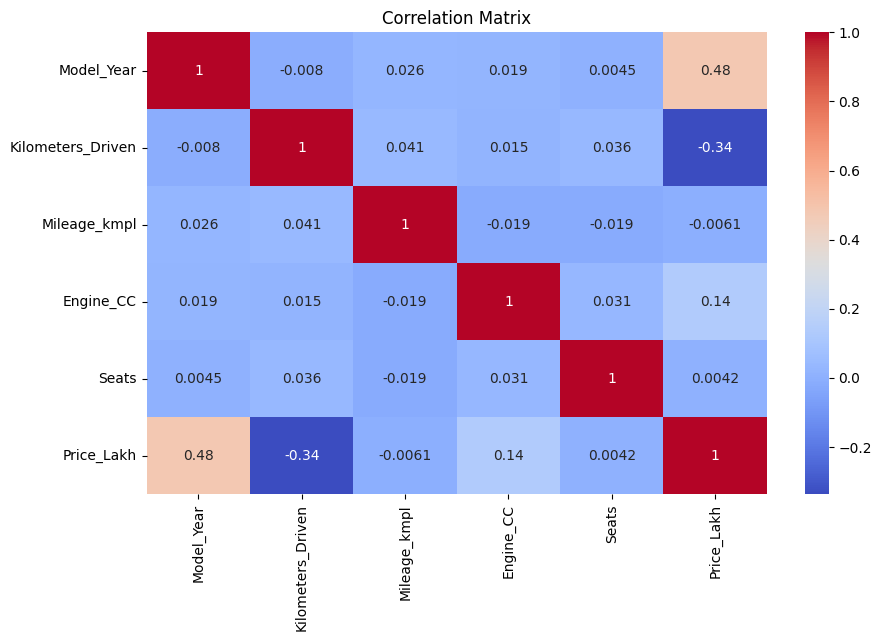

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())

   Model_Year  Kilometers_Driven  Mileage_kmpl  Engine_CC  Seats  Price_Lakh  \
0        2023             170250          14.7       1370      4        9.42   
1        2018             148737          13.1       1656      7       10.66   
2        2008               5534          22.7       2584      5        7.05   
3        2017              96828          23.6       2527      7       11.95   
4        2012              41132          18.1       1847      6       11.21   

   Brand_Hyundai  Brand_Mahindra  Brand_Maruti  Brand_Tata  Brand_Toyota  \
0          False            True         False       False         False   
1          False           False         False       False         False   
2          False           False         False        True         False   
3          False           False         False       False         False   
4          False           False         False       False         False   

   Fuel_Type_Diesel  Fuel_Type_Electric  Fuel_Type_Petrol  \
0

In [ ]:
X = df_encoded.drop("Price_Lakh", axis=1)
y = df_encoded["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coeff_df)

                     Coefficient
Model_Year              0.301078
Kilometers_Driven      -0.000020
Mileage_kmpl            0.008518
Engine_CC               0.000785
Seats                  -0.017776
Brand_Hyundai          -4.547421
Brand_Mahindra         -1.607148
Brand_Maruti           -5.971066
Brand_Tata             -2.967993
Brand_Toyota            1.408852
Fuel_Type_Diesel        0.036425
Fuel_Type_Electric      0.058234
Fuel_Type_Petrol       -0.039215
Transmission_Manual    -0.046531
Owner_Type_Second       0.061677
Owner_Type_Third        0.115665


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.8195186624699339
MSE: 1.0284354521117822
RMSE: 1.0141180661598443
R2 Score: 0.9169418112172951


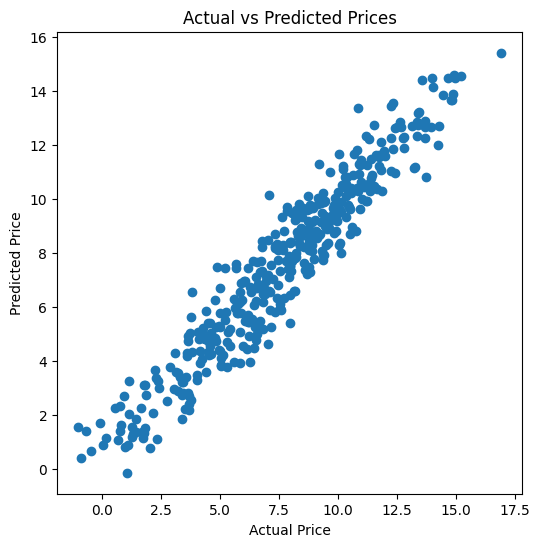

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

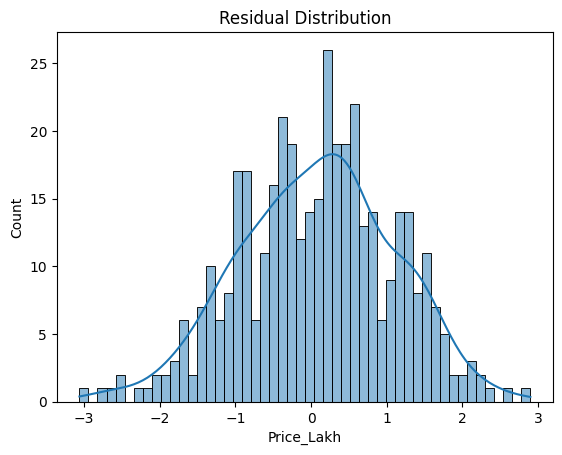

In [ ]:
sns.histplot(y_test - y_pred, bins=50, kde=True)
plt.title("Residual Distribution")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison.head(20))  # show first 20 rows

    Actual Price  Predicted Price
0           6.62         6.838370
1           9.89         8.795777
2           8.96         7.753323
3           8.87         8.287869
4          15.22        14.536920
5           4.55         4.560268
6          11.40        10.766250
7           9.62         9.136084
8           7.95         5.387082
9           3.64         4.747658
10          3.66         2.165314
11          8.77         8.379043
12          7.96         7.524880
13          8.68         7.212823
14          8.16         6.570913
15          8.33         9.396509
16          7.04         7.186543
17          8.16         7.821551
18          9.90         9.779472
19         13.96        14.479097


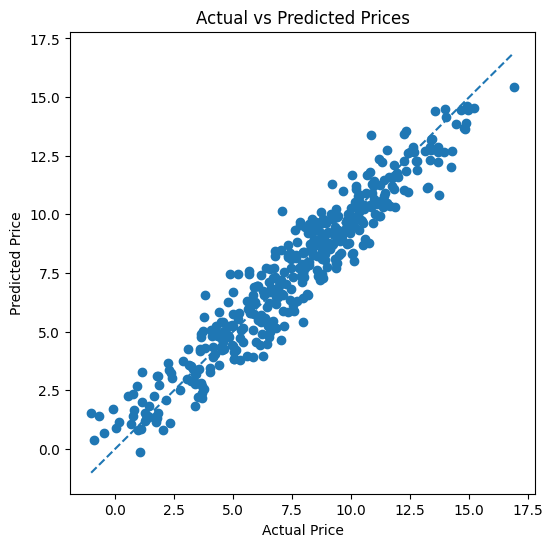

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

**MULTIPLE LINEAR REGRESSION**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Price_Lakh", axis=1)   # multiple independent variables
y = df["Price_Lakh"]                # dependent variable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

Intercept: -596.2345204137249
                Feature  Coefficient
0            Model_Year     0.301078
1     Kilometers_Driven    -0.000020
2          Mileage_kmpl     0.008518
3             Engine_CC     0.000785
4                 Seats    -0.017776
5         Brand_Hyundai    -4.547421
6        Brand_Mahindra    -1.607148
7          Brand_Maruti    -5.971066
8            Brand_Tata    -2.967993
9          Brand_Toyota     1.408852
10     Fuel_Type_Diesel     0.036425
11   Fuel_Type_Electric     0.058234
12     Fuel_Type_Petrol    -0.039215
13  Transmission_Manual    -0.046531
14    Owner_Type_Second     0.061677
15     Owner_Type_Third     0.115665


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0    6.62   6.838370
1    9.89   8.795777
2    8.96   7.753323
3    8.87   8.287869
4   15.22  14.536920
5    4.55   4.560268
6   11.40  10.766250
7    9.62   9.136084
8    7.95   5.387082
9    3.64   4.747658


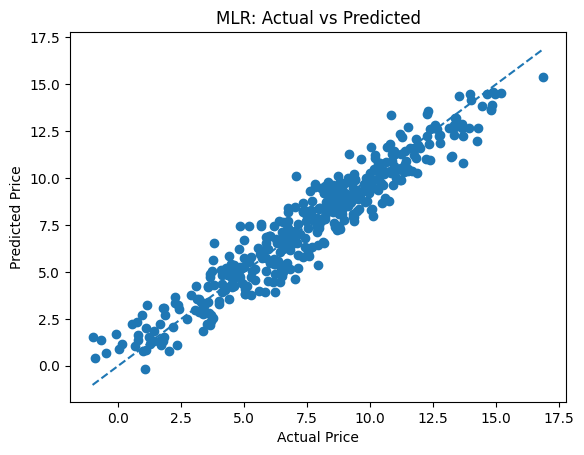

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("MLR: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.8195186624699339
R2 Score: 0.9169418112172951


**SVM ALGORITHM (REGRESSION)**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))

In [ ]:
model = SVR(kernel='rbf')  # radial basis function kernel
model.fit(X_train, y_train.ravel())

SVR()

In [ ]:
y_pred_scaled = model.predict(X_test)

# Convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.9408478623178331
R2 Score: 0.8927288053587623


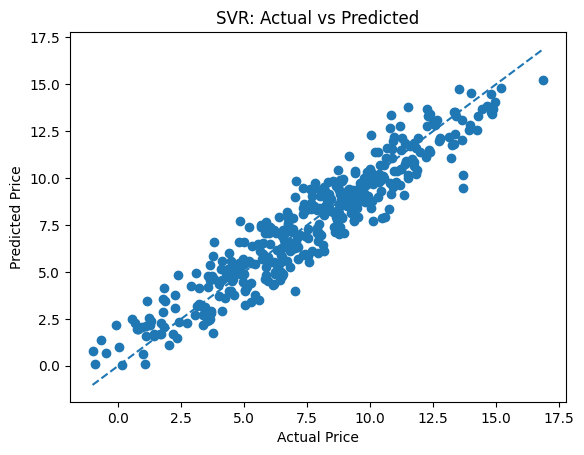

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

**LOGISTIC REGRESSION (CLASSIFICATION)**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
# Create 3 classes
df["Price_Category"] = pd.cut(
    df["Price_Lakh"],
    bins=[0, 5, 10, 20],
    labels=["Low", "Medium", "High"]
)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop(["Price_Lakh", "Price_Category_Medium", "Price_Category_High"], axis=1)

# Target (0,1,2)
y = pd.cut(
    df["Price_Lakh"],
    bins=[df["Price_Lakh"].min(), 5, 10, df["Price_Lakh"].max()],
    labels=[0,1,2],
    include_lowest=True
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8575

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83        99
           1       0.83      0.89      0.86       199
           2       0.93      0.82      0.88       102

    accuracy                           0.86       400
   macro avg       0.87      0.85      0.86       400
weighted avg       0.86      0.86      0.86       400



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[ 82  17   0]
 [ 16 177   6]
 [  0  18  84]]


**RIDGE REGRESSION**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Ridge(alpha=1.0)   # alpha = regularization strength
model.fit(X_train, y_train)

Ridge()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.8196398444185451
R2 Score: 0.916953488839783


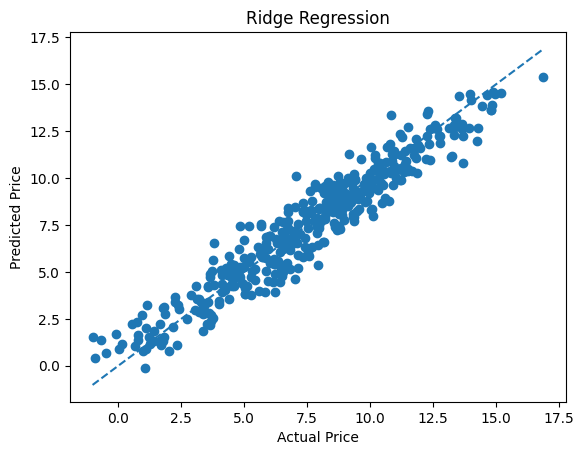

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

**LASSO RERESSION**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Lasso(alpha=0.1)   # try different alpha values
model.fit(X_train, y_train)

Lasso(alpha=0.1)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.8823291427569422
R2 Score: 0.9042415862934414


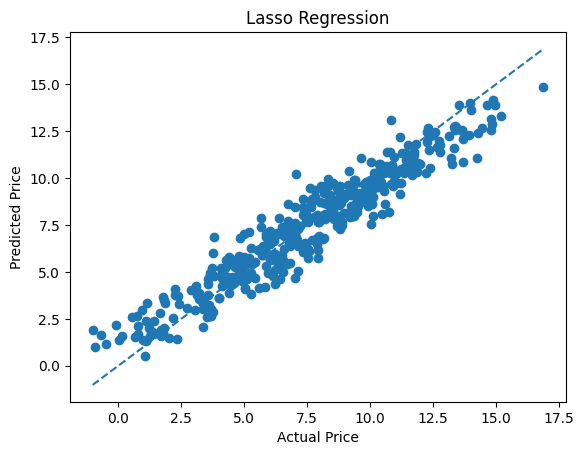

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

In [ ]:
print("Coefficients:", model.coef_)

Coefficients: [ 1.56245934 -1.00718721  0.          0.37315791 -0.         -1.34833765
 -0.23370332 -1.91727042 -0.75664193  0.69776813  0.          0.
 -0.         -0.          0.          0.        ]


**KNN REGRESSION**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = KNeighborsRegressor(n_neighbors=5)  # k = 5
model.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 1.221015
R2 Score: 0.80720624492117


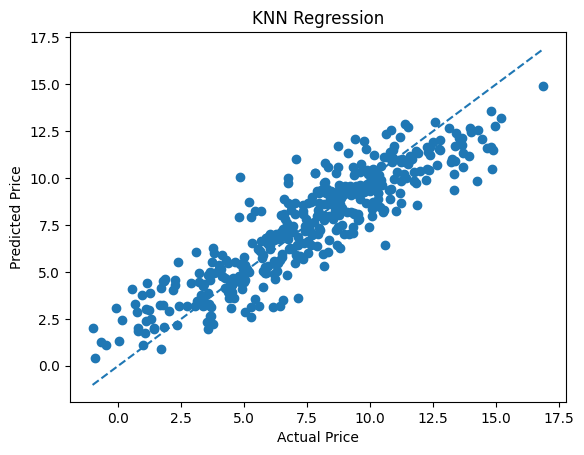

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN Regression")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

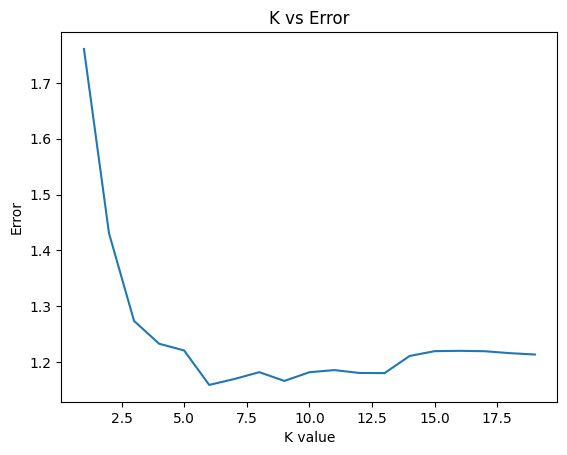

In [ ]:
errors = []

for k in range(1, 20):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    errors.append(mean_absolute_error(y_test, y_pred))

plt.plot(range(1,20), errors)
plt.xlabel("K value")
plt.ylabel("Error")
plt.title("K vs Error")
plt.show()

**DECISION TREE**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 1.218925
R2 Score: 0.8140105242051863


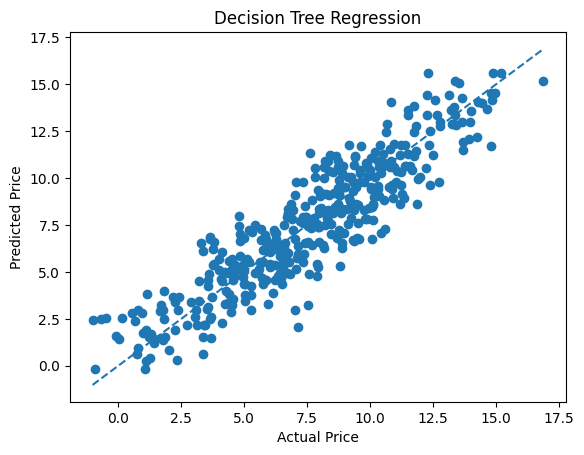

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Regression")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

**RANDOM FOREST**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("CAR_PRICE.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.8957912499999998
R2 Score: 0.8983905523789788


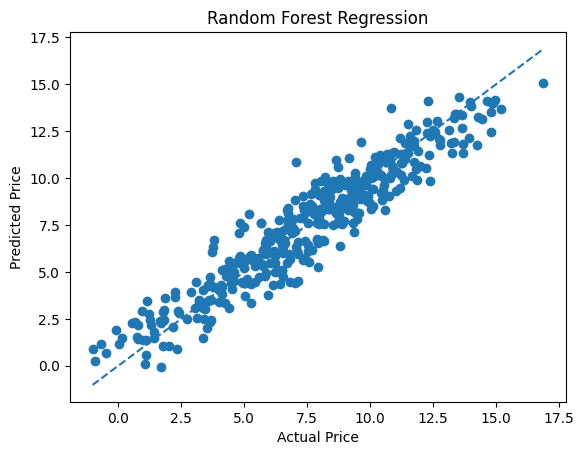

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Regression")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

**COMPARISION**

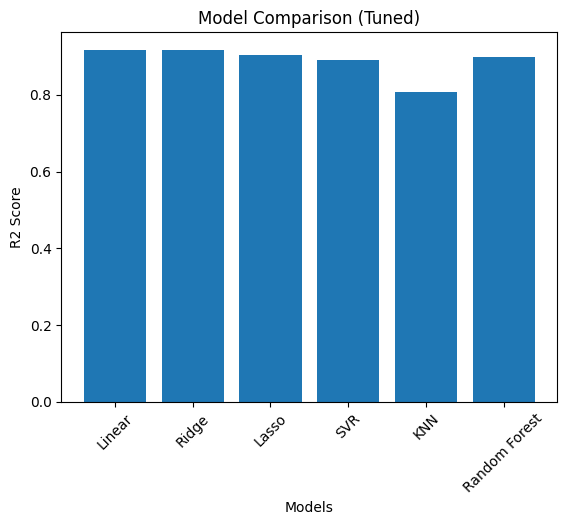

{'Linear': 0.9169418112172951, 'Ridge': 0.916953488839783, 'Lasso': 0.9042415862934414, 'SVR': 0.891300340830506, 'KNN': 0.80720624492117, 'Random Forest': 0.8983905523789788}


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv('CAR_PRICE.csv')

# Preprocess
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
results["Linear"] = r2_score(y_test, lr.predict(X_test))

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
results["Ridge"] = r2_score(y_test, ridge.predict(X_test_scaled))

# Lasso (FIXED 🔥)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
results["Lasso"] = r2_score(y_test, lasso.predict(X_test_scaled))

# SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
results["SVR"] = r2_score(y_test, svr.predict(X_test_scaled))

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
results["KNN"] = r2_score(y_test, knn.predict(X_test_scaled))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
results["Random Forest"] = r2_score(y_test, rf.predict(X_test))

# Plot
models = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(models, scores)
plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (Tuned)")
plt.show()

print(results)